# Customer Churn Prediction - Entrenamiento de Modelos

**Objetivo:**
En este notebook entrenaremos y evaluaremos varios modelos de Machine Learning para predecir la pérdida de clientes (Churn).
Se entrenarán modelos base, se evaluará su rendimiento mediante métricas clave y se compararán los resultados para seleccionar el modelo más prometedor para optimización posterior.

**Modelos a entrenar:**
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost

Se incluirán visualizaciones de desempeño, matrices de confusión y curvas ROC para cada modelo.


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, RocCurveDisplay
)

# Configuración general
sns.set(style='whitegrid')
np.random.seed(42)

In [33]:
#Quitar warnings
import warnings
warnings.filterwarnings('ignore')

## 🔹 Carga de datos preprocesados

En esta sección cargamos los datasets que ya han sido preprocesados en el Notebook 2.
Esto asegura que el Notebook de modelado sea independiente y reproducible.

Variables disponibles:
- `X_train`, `X_test`: features escaladas y codificadas
- `y_train`, `y_test`: variable objetivo binaria


In [34]:
#Usamos las variables ya preprocesadas en el notebook 02
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

## ⚙️ Entrenamiento de modelos base

Entrenaremos cuatro modelos iniciales con **hiperparámetros por defecto**, únicamente para comparar su rendimiento base:

1. **Logistic Regression** – modelo lineal de referencia.
2. **Decision Tree** – modelo interpretable basado en reglas.
3. **Random Forest** – ensamblado de árboles con reducción de varianza.
4. **XGBoost** – modelo de boosting altamente eficiente.

Evaluaremos su rendimiento usando las siguientes métricas:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

In [35]:
# Inicializamos los modelos
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = []

# Asegurar que y_train y y_test sean Series para compatibilidad
y_train_series = pd.Series(y_train)
y_test_series = pd.Series(y_test)

# Detectar si las etiquetas son texto o números
is_text_labels = y_test_series.dtype == 'O'

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Si son etiquetas de texto ("Yes"/"No"), convertir a binario
    if is_text_labels:
        y_true = (y_test_series == 'Yes').astype(int)
        y_pred_binary = (y_pred == 'Yes').astype(int)
    else:
        y_true = y_test_series
        y_pred_binary = y_pred

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred_binary),
        "Precision": precision_score(y_true, y_pred_binary),
        "Recall": recall_score(y_true, y_pred_binary),
        "F1-Score": f1_score(y_true, y_pred_binary),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }
    results.append(metrics)

results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.804549,0.650456,0.572193,0.608819,0.836071
3,XGBoost,0.778252,0.589080,0.548128,0.567867,0.819647
2,Random Forest,0.788913,0.627907,0.505348,0.560000,0.814967
1,Decision Tree,0.711443,0.456522,0.449198,0.452830,0.627744


## 📊 Comparación visual de métricas entre modelos

En esta sección visualizamos las métricas de rendimiento principales para comparar los modelos base.
Nos centraremos especialmente en el **F1-Score** (balance entre precisión y recall) y en el **ROC-AUC** (capacidad de discriminación global del modelo).

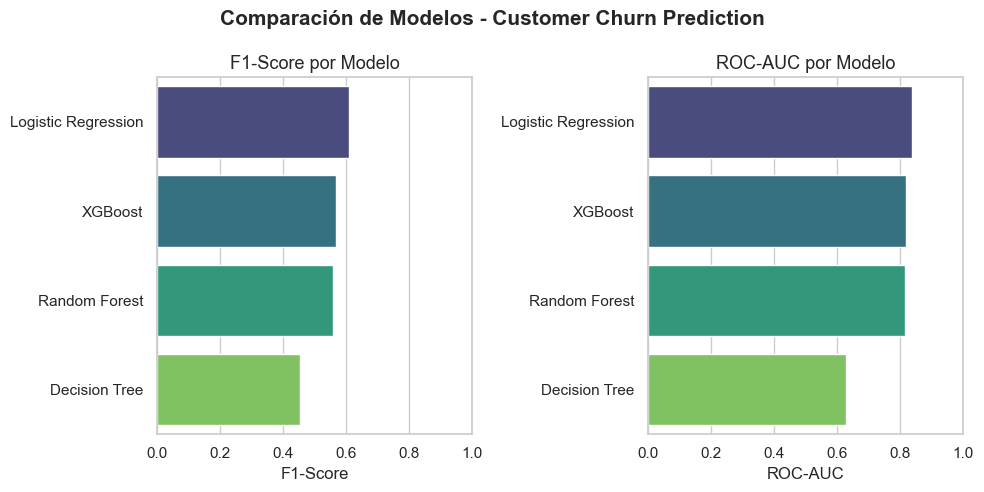

In [36]:
plt.figure(figsize=(10, 5))
metrics_to_plot = ["F1-Score", "ROC-AUC"]

for i, metric in enumerate(metrics_to_plot):
    plt.subplot(1, 2, i + 1)
    sns.barplot(
        data=results_df,
        y="Model", x=metric,
        palette="viridis", order=results_df.sort_values(metric, ascending=False)["Model"]
    )
    plt.title(f"{metric} por Modelo", fontsize=13)
    plt.xlabel(metric)
    plt.ylabel("")
    plt.xlim(0, 1)

plt.suptitle("Comparación de Modelos - Customer Churn Prediction", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 🧩 Evaluación detallada de los modelos

En esta sección analizamos el desempeño de cada modelo en mayor profundidad mediante:

1. **Matriz de confusión:** muestra cómo se distribuyen las predicciones correctas e incorrectas.
2. **Curva ROC:** permite visualizar la capacidad del modelo para distinguir entre clientes que abandonan y los que permanecen.

Esto nos ayudará a entender no solo qué modelo rinde mejor globalmente, sino también **cómo** lo hace.

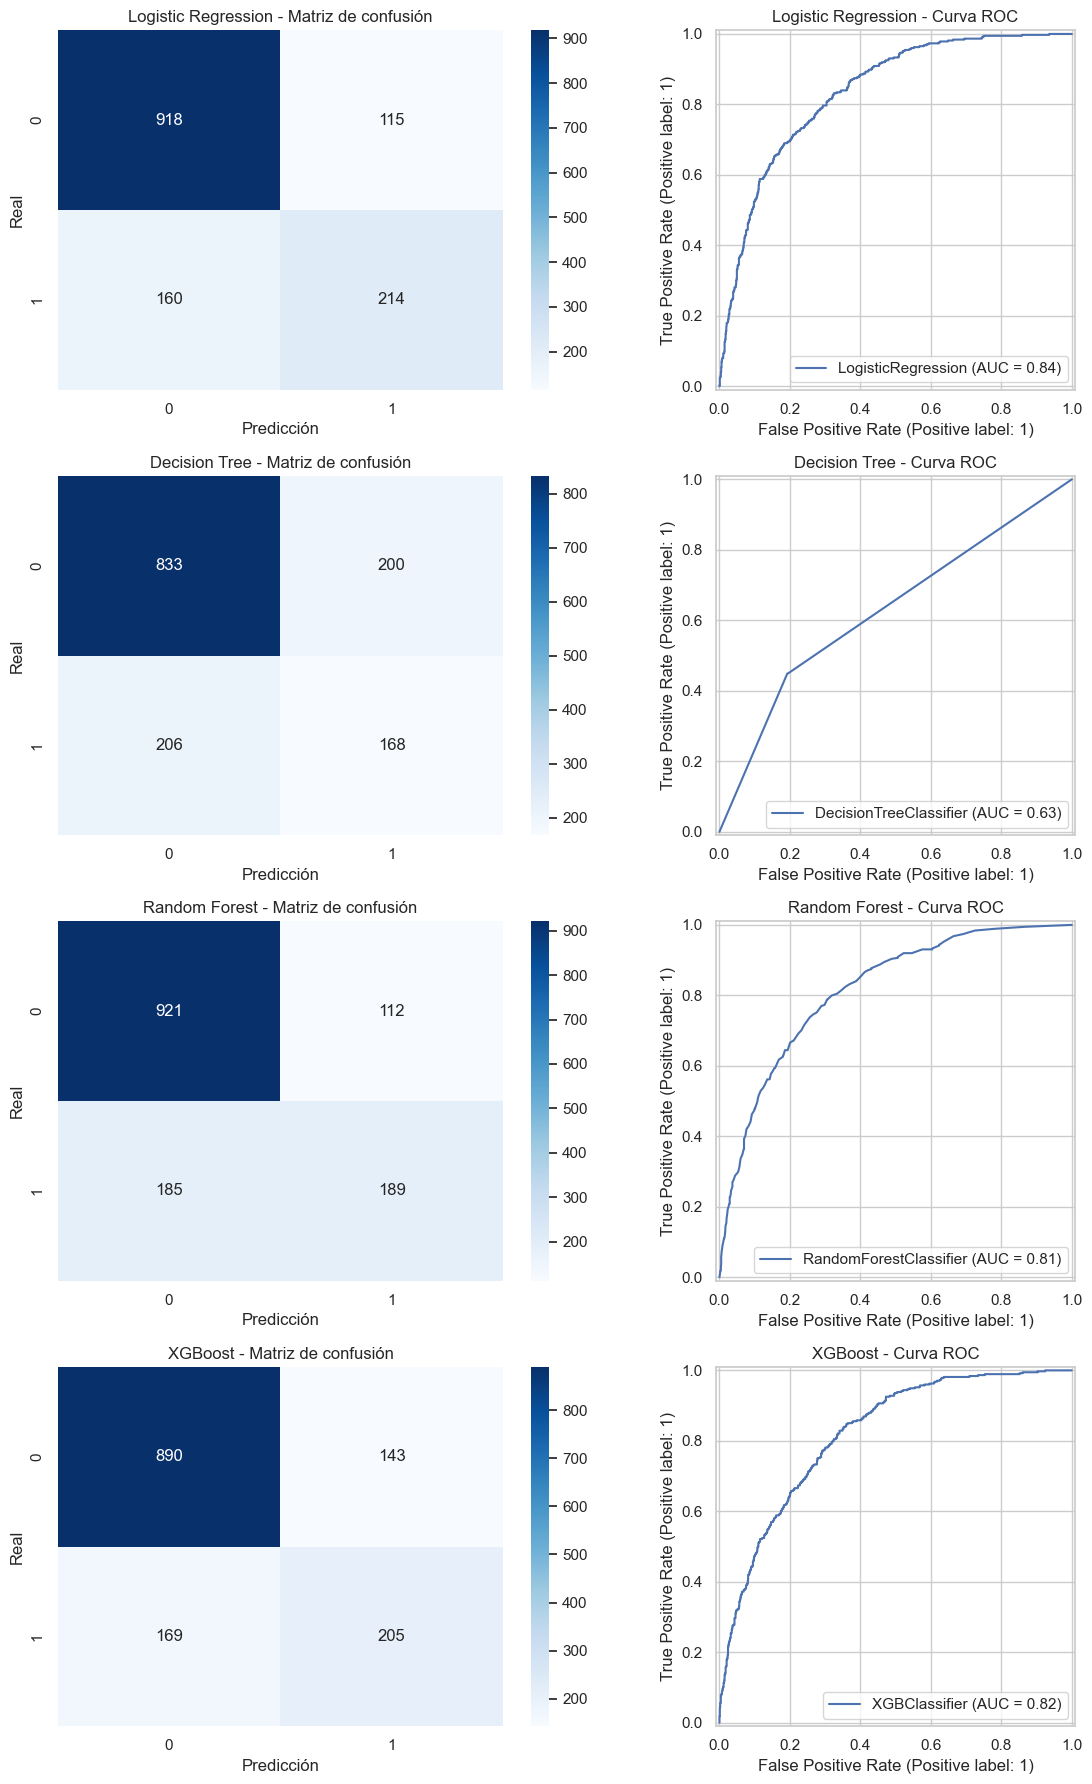

In [37]:
fig, axes = plt.subplots(4, 2, figsize=(12, 18))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    # Predicciones
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Convertir a binario si es texto
    if y_test_series.dtype == 'O':
        y_true = (y_test_series == 'Yes').astype(int)
        y_pred_binary = (y_pred == 'Yes').astype(int)
    else:
        y_true = y_test_series
        y_pred_binary = y_pred

    # --- Matriz de confusión ---
    cm = confusion_matrix(y_true, y_pred_binary)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx * 2])
    axes[idx * 2].set_title(f"{name} - Matriz de confusión")
    axes[idx * 2].set_xlabel("Predicción")
    axes[idx * 2].set_ylabel("Real")

    # --- Curva ROC ---
    RocCurveDisplay.from_estimator(model, X_test, y_true, ax=axes[idx * 2 + 1])
    axes[idx * 2 + 1].set_title(f"{name} - Curva ROC")

plt.tight_layout()
plt.show()

## 🔧 Optimización de hiperparámetros

Vamos a aplicar una búsqueda de hiperparámetros con validación cruzada para exprimir el máximo rendimiento de los modelos más prometedores:
- **Logistic Regression**: ajuste del regularizador.
- **XGBoost**: ajuste de profundidad, tasa de aprendizaje y número de árboles.

In [38]:
#Cross-validation y Grid Search
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

# Definimos los modelos y sus hiperparámetros
param_grid_log = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga']
}

param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

# Configuramos la validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression
log_model = LogisticRegression(max_iter=1000, random_state=42)
grid_log = GridSearchCV(log_model, param_grid_log, cv=cv, scoring='roc_auc', n_jobs=-1)
grid_log.fit(X_train, y_train)
print("Best Logistic Regression Params:", grid_log.best_params_)
print("Best Logistic Regression ROC-AUC:", grid_log.best_score_)

# XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
grid_xgb = GridSearchCV(xgb_model, param_grid_xgb, cv=cv, scoring='roc_auc', n_jobs=-1)
grid_xgb.fit(X_train, y_train)
print("Best XGBoost Params:", grid_xgb.best_params_)
print("Best XGBoost ROC-AUC:", grid_xgb.best_score_)

Best Logistic Regression Params: {'C': 10, 'solver': 'saga'}
Best Logistic Regression ROC-AUC: 0.8462947516742652
Best XGBoost Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
Best XGBoost ROC-AUC: 0.8492574117113543


# 🔍 Comparación de Matrices de Confusión: Modelos Optimizados

Tras el ajuste de hiperparámetros mediante **Grid Search** y validación cruzada estratificada, analizaremos el **comportamiento real de los modelos optimizados** (Logistic Regression y XGBoost) sobre el conjunto de test.

El objetivo de esta comparación no es solo evaluar su *performance* global (ROC-AUC), sino entender **cómo se distribuyen sus aciertos y errores**:

| Métrica | Descripción |
|----------|--------------|
| ✅ **True Positive (TP)** | Clientes correctamente identificados como *churn* (predicción acertada de abandono). |
| ❌ **False Negative (FN)** | Clientes que abandonan pero el modelo no los detecta (error más costoso para el negocio). |
| ❌ **False Positive (FP)** | Clientes fieles clasificados erróneamente como *churn* (error menos grave, implica ofrecer incentivos innecesarios). |
| ✅ **True Negative (TN)** | Clientes correctamente identificados como no *churn*. |

Dado que en el sector telecomunicaciones **retener un cliente cuesta mucho menos que adquirir uno nuevo**, el **objetivo principal es minimizar los *False Negatives (FN)*** y maximizar el **Recall (Churn)**, incluso si esto implica un leve aumento en los *False Positives*.

A continuación, se compararán gráficamente las matrices de confusión de ambos modelos optimizados, junto con sus métricas clave (precision y recall para la clase *Churn*), con el fin de determinar **cuál modelo ofrece el mejor equilibrio entre retención y precisión operativa**.

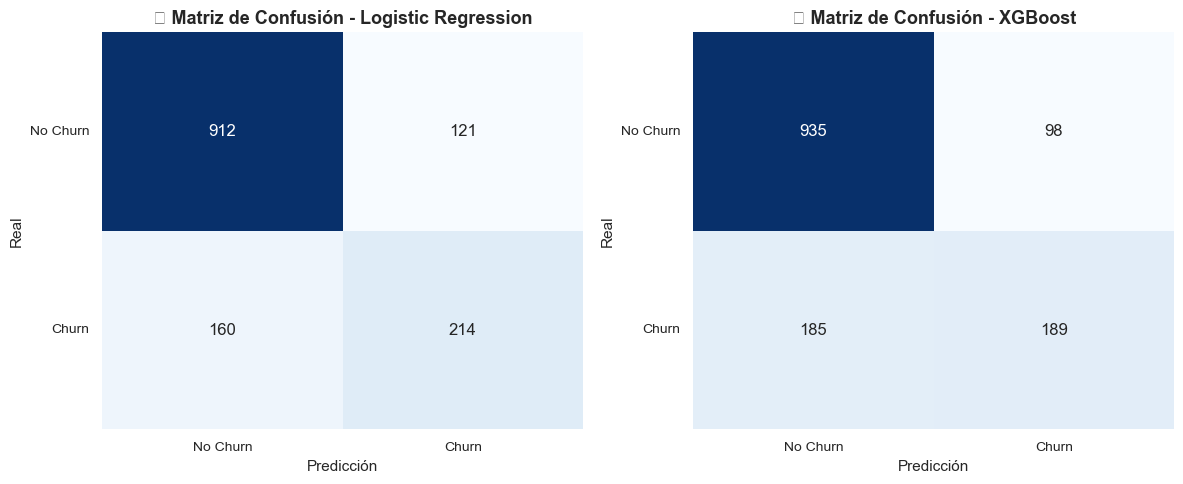


🔹 Comparativa de métricas principales:


,Model,Precision (Churn),Recall (Churn),F1-score (Churn),Accuracy
0,Logistic Regression,0.639,0.572,0.604,0.800
1,XGBoost,0.659,0.505,0.572,0.799


In [40]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# --- Predicciones ---
y_pred_log = grid_log.best_estimator_.predict(X_test)
y_pred_xgb = grid_xgb.best_estimator_.predict(X_test)

# --- Matrices de confusión ---
cm_log = confusion_matrix(y_test, y_pred_log)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# --- Reportes de clasificación ---
report_log = classification_report(y_test, y_pred_log, output_dict=True, zero_division=0)
report_xgb = classification_report(y_test, y_pred_xgb, output_dict=True, zero_division=0)

# --- Visualización lado a lado ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, cm, model_name in zip(axes, [cm_log, cm_xgb], ["Logistic Regression", "XGBoost"]):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax, annot_kws={"size": 12})
    ax.set_title(f"📊 Matriz de Confusión - {model_name}", fontsize=13, weight='bold')
    ax.set_xlabel("Predicción", fontsize=11)
    ax.set_ylabel("Real", fontsize=11)
    ax.set_xticklabels(["No Churn", "Churn"], fontsize=10)
    ax.set_yticklabels(["No Churn", "Churn"], fontsize=10, rotation=0)

plt.tight_layout()
plt.show()

# --- Métricas comparativas ---
metrics = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'Precision (Churn)': [report_log['1']['precision'], report_xgb['1']['precision']],
    'Recall (Churn)': [report_log['1']['recall'], report_xgb['1']['recall']],
    'F1-score (Churn)': [report_log['1']['f1-score'], report_xgb['1']['f1-score']],
    'Accuracy': [report_log['accuracy'], report_xgb['accuracy']]
})

print("\n🔹 Comparativa de métricas principales:")
display(metrics.round(3))

## 🧩 Comparación ajustada de Matrices de Confusión: Logistic Regression vs XGBoost

A continuación se muestran los valores extraídos de las matrices de confusión (test set) y las métricas calculadas:

### 🔹 Logistic Regression
- **True Negatives (TN):** 912
- **False Positives (FP):** 121
- **False Negatives (FN):** 160
- **True Positives (TP):** 214

Métricas (clase *Churn* = 1):
- **Precision:** 0.639
- **Recall:** 0.572
- **F1-score:** 0.604
- **Accuracy:** 0.800

### 🔹 XGBoost (optimizado)
- **True Negatives (TN):** 935
- **False Positives (FP):** 98
- **False Negatives (FN):** 185
- **True Positives (TP):** 189

Métricas (clase *Churn* = 1):
- **Precision:** 0.659
- **Recall:** 0.505
- **F1-score:** 0.572
- **Accuracy:** 0.799

---

### ⚖️ Interpretación y recomendación operativa

- **Logistic Regression** tiene **menos FNs** (160 vs 185) y **mejor Recall** (0.572 vs 0.505). También presenta **mejor F1-score** (0.604 vs 0.572) y una Accuracy prácticamente idéntica.
- En este contexto, donde **perder un cliente (FN)** suele costar más que un **falso positivo**, reducir los FN es prioritario.
- Por tanto, **Logistic Regression es la mejor opción actualmente**: detecta más churn reales y ofrece un mejor equilibrio entre precisión y sensibilidad.